# **Import Library**

Tahap ini memuat semua library yang dibutuhkan untuk akses data, pengolahan raster, dan inference.

- Library utilitas: os, time, pickle, pathlib, dotenv
- Library data dan visualisasi: numpy, pandas, matplotlib
- Library geospasial: rasterio, geopandas, shapely
- Library akses data: pystac_client, planetary_computer, h5py
- Library fitur dan model: skimage (GLCM), tensorflow (Dynamic World)

In [1]:
import os
import h5py
import time
import pickle
import shapely
import rasterio
import requests
import tempfile
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import tensorflow as tf
from pathlib import Path
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import planetary_computer as pc
from pystac_client import Client
from urllib.parse import urlparse

from rasterio.enums import Resampling
from rasterio.windows import from_bounds
from shapely.geometry import Polygon, shape
from shapely.geometry import shape as _shape
from rasterio.warp import reproject, transform_bounds
from skimage.feature import graycomatrix, graycoprops
from rasterio.transform import Affine, array_bounds, from_origin

from pystac_client.stac_api_io import StacApiIO
from pystac_client.exceptions import APIError

warnings.filterwarnings("ignore")

# **Config**

Tahap ini menyiapkan kredensial, parameter global, koneksi katalog data, dan area studi (AOI).

- Membaca kredensial NASA dari `.env`
- Menetapkan resolusi 30 m, CRS `EPSG:32648`, dan rentang waktu 2025
- Membuka tiga klien STAC: NASA ORNL, Planetary Computer, dan NASA LPCLOUD
- Mendefinisikan AOI Bogor beserta GeoJSON dan batas koordinatnya

In [2]:
load_dotenv()
username_nasa = os.getenv("USERNAME_NASA")
password_nasa = os.getenv("PASSWORD_NASA")


In [3]:
scale=30
crs = "EPSG:32648"
datetime = "2025-01-01/2026-01-01"

In [4]:
STAC_IO = StacApiIO(timeout=(15, 60))

nasa_client = Client.open("https://cmr.earthdata.nasa.gov/stac/ORNL_CLOUD", stac_io=STAC_IO)
planetary_client = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace, stac_io=STAC_IO)
lpcloud_client = Client.open("https://cmr.earthdata.nasa.gov/stac/LPCLOUD", stac_io=STAC_IO)

In [5]:
aoi = Polygon([
    (106.68886864068807, -6.48395642490592),
    (106.68886864068807, -6.529835872702448),
    (106.75255501153768, -6.529835872702448),
    (106.75255501153768, -6.48395642490592),
    (106.68886864068807, -6.48395642490592),
])
geometry = aoi.__geo_interface__
left, bottom, right, top = aoi.bounds

# **SpatioTemporal Asset Catalog (STAC) API**

Tahap ini mencari dan memuat data satelit dari katalog STAC untuk tiap sumber data.

- Fungsi pembantu untuk mengambil URL asset dan mencari item dengan retry
- **Sentinel-2:** scene L2A berawan < 10%, lalu tampilan RGB
- **Sentinel-1:** scene RTC descending, lalu tampilan VV dalam dB
- **GLO-30:** tile DEM pada AOI, lalu tampilan elevasi
- **GEDI:** login Earthdata, pasangkan granule L4A dan L2A, baca titik di AOI, filter kualitas, lalu plot AGBD dan RH98
- **Dynamic World:** muat model, prediksi probabilitas 9 kelas, lalu tampilkan peta kelas dominan

In [6]:
def extract_asset_urls(item, asset_keys):
    return {key: item.assets[key].href for key in asset_keys if key in item.assets}

In [7]:
def item_records(item, asset_keys, extra_properties=None):
    return {                                                
        "id": item.id,
        "datetime": item.datetime.isoformat() if item.datetime else None,
        "urls": extract_asset_urls(item, asset_keys),
        "properties": {
            key: item.properties.get(key)
            for key in (extra_properties or [])
            if key in item.properties
        },
    }

In [8]:
def stac_items(client, limit=3, retries=2, **search_kwargs):
    for attempt in range(retries):
        try:
            return list(client.search(max_items=limit, **search_kwargs).items())
        except (requests.exceptions.RequestException, APIError, Exception):
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)

### **Sentinel-2**

In [9]:
def collect_sentinel2(bands, cloud_cover=10, max_scenes=1):
    items = stac_items(
        planetary_client, limit=max_scenes,
        collections=["sentinel-2-l2a"], intersects=aoi.__geo_interface__, datetime=datetime,
        query={"eo:cloud_cover": {"lt": cloud_cover}},
        sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
    )
    records = [item_records(item, bands, extra_properties=["eo:cloud_cover"]) for item in items]
    return sorted(records, key=lambda r: r["properties"].get("eo:cloud_cover", float("inf")))[:max_scenes]

In [10]:
s2_records = collect_sentinel2(
    bands=["visual", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12"],
    cloud_cover=10,
)

In [11]:
s2_records[0]

{'id': 'S2B_MSIL2A_20250826T025529_R032_T48MXT_20250826T063629',
 'datetime': '2025-08-26T02:55:29.024000+00:00',
 'urls': {'visual': 'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/48/M/XT/2025/08/26/S2B_MSIL2A_20250826T025529_N0511_R032_T48MXT_20250826T063629.SAFE/GRANULE/L2A_T48MXT_A044245_20250826T031447/IMG_DATA/R10m/T48MXT_20250826T025529_TCI_10m.tif?st=2026-10-07T07%3A26%3A21Z&se=2026-10-08T08%3A11%3A21Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-08T07%3A26%3A13Z&ske=2026-10-15T07%3A26%3A13Z&sks=b&skv=2025-07-05&sig=qqlPi9okbXn/CDk1PxU%2BeX9rH8z9d55jzMlkpULxlDw%3D',
  'B02': 'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/48/M/XT/2025/08/26/S2B_MSIL2A_20250826T025529_N0511_R032_T48MXT_20250826T063629.SAFE/GRANULE/L2A_T48MXT_A044245_20250826T031447/IMG_DATA/R10m/T48MXT_20250826T025529_B02_10m.tif?st=2026-10-07T07%3A26%3A21Z&se=2026-10-08T08%3A11%3A21Z&sp=rl&sv=2025-07-05&sr=c&sko

In [12]:
print(f"Jumlah scene tersedia: {len(s2_records)}")
for index, record in enumerate(s2_records, start=1):
    print(
        f"{index:02d}. {record['id']} | "
        f"cloud={record['properties'].get('eo:cloud_cover', 'n/a')}% | "
        f"image assets={sorted(record['urls'])}"
    )

Jumlah scene tersedia: 1
01. S2B_MSIL2A_20250826T025529_R032_T48MXT_20250826T063629 | cloud=0.743737% | image assets=['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B11', 'B12', 'visual']


In [13]:
def collect_scene_urls(scene, bands):
    available_urls = scene.get("urls", {})
    return {b: available_urls[b] for b in bands if b in available_urls}

In [14]:
s2_scene = collect_scene_urls(s2_records[0], ["visual", "B02", "B03", "B04", "B08", "B11", "B12"])
s2_scene

{'visual': 'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/48/M/XT/2025/08/26/S2B_MSIL2A_20250826T025529_N0511_R032_T48MXT_20250826T063629.SAFE/GRANULE/L2A_T48MXT_A044245_20250826T031447/IMG_DATA/R10m/T48MXT_20250826T025529_TCI_10m.tif?st=2026-10-07T07%3A26%3A21Z&se=2026-10-08T08%3A11%3A21Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-08T07%3A26%3A13Z&ske=2026-10-15T07%3A26%3A13Z&sks=b&skv=2025-07-05&sig=qqlPi9okbXn/CDk1PxU%2BeX9rH8z9d55jzMlkpULxlDw%3D',
 'B02': 'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/48/M/XT/2025/08/26/S2B_MSIL2A_20250826T025529_N0511_R032_T48MXT_20250826T063629.SAFE/GRANULE/L2A_T48MXT_A044245_20250826T031447/IMG_DATA/R10m/T48MXT_20250826T025529_B02_10m.tif?st=2026-10-07T07%3A26%3A21Z&se=2026-10-08T08%3A11%3A21Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-08T07%3A26%3A13Z&ske=2026-10-

In [15]:
def load_raster_window(asset_url, bounds, visual_s2=False, out_shape=(1024, 1024)):
    with rasterio.open(asset_url) as source:
        raster_bounds = transform_bounds(
            "EPSG:4326", source.crs, *bounds
        )
        area_window = from_bounds(*raster_bounds, transform=source.transform)
        if visual_s2:
            data = source.read(
                indexes=[1, 2, 3],
                window=area_window,
                out_shape=(3, *out_shape),
                masked=True,
            ).astype("float32")
        else:
            data = source.read(
                indexes=1,
                window=area_window,
                out_shape=out_shape,
                masked=True,
            ).astype("float32")
    return data

In [16]:
loaded_visual = load_raster_window(s2_scene["visual"], bounds=(left, bottom, right, top),visual_s2=True, out_shape=(720, 1024))

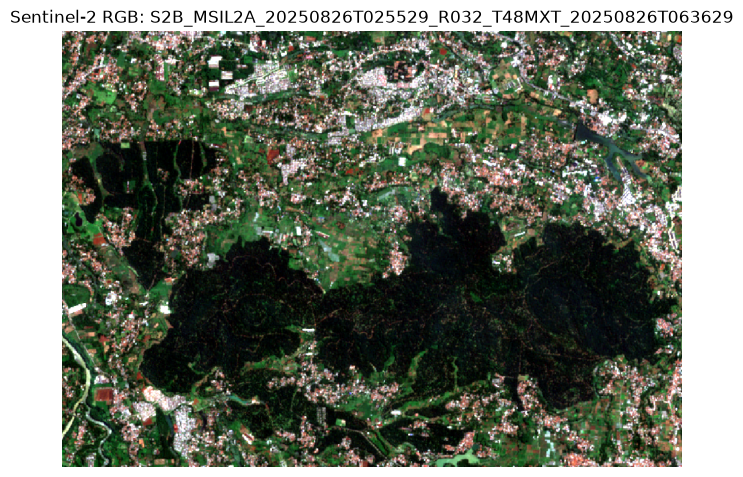

In [17]:
rgb = np.moveaxis(loaded_visual, 0, -1).filled(np.nan)
for channel in range(3):
    low, high = np.nanpercentile(rgb[..., channel], (2, 98))
    rgb[..., channel] = np.clip((rgb[..., channel] - low) / (high - low), 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title(f"Sentinel-2 RGB: {s2_records[0]['id']}")
plt.axis("off")
plt.show()

### **Sentinel-1**

In [18]:
def collect_sentinel1(polarizations=("vv", "vh"), orbit_direction="descending", max_scenes=1):
    query = {"sat:orbit_state": {"eq": orbit_direction}} if orbit_direction else None
    items = stac_items(
        planetary_client, limit=max_scenes,
        collections=["sentinel-1-rtc"], intersects=aoi.__geo_interface__, datetime=datetime,
        query=query, sortby=[{"field": "properties.datetime", "direction": "asc"}],
    )
    return [item_records(item, polarizations, extra_properties=["sat:orbit_state"])
            for item in list(items)[:max_scenes]]


In [19]:
s1_records = collect_sentinel1(polarizations=["vv", "vh"], orbit_direction="descending")
s1_records[0]

{'id': 'S1A_IW_GRDH_1SDV_20250519T223405_20250519T223432_059269_075AEA_rtc',
 'datetime': '2025-05-19T22:34:19.261942+00:00',
 'urls': {'vv': 'https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2025/5/19/IW/DV/S1A_IW_GRDH_1SDV_20250519T223405_20250519T223432_059269_075AEA_DB83/measurement/iw-vv.rtc.tiff?st=2026-10-07T07%3A26%3A29Z&se=2026-10-08T08%3A11%3A29Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-08T07%3A25%3A42Z&ske=2026-10-15T07%3A25%3A42Z&sks=b&skv=2025-07-05&sig=A/PUJ/xnHDvw8gjx%2BvHdlUp7679S9/%2BSPiqYClS7Xok%3D',
  'vh': 'https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2025/5/19/IW/DV/S1A_IW_GRDH_1SDV_20250519T223405_20250519T223432_059269_075AEA_DB83/measurement/iw-vh.rtc.tiff?st=2026-10-07T07%3A26%3A29Z&se=2026-10-08T08%3A11%3A29Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-08

In [20]:
print(f"Jumlah scene tersedia: {len(s1_records)}")
for index, record in enumerate(s1_records, start=1):
    print(
        f"{index:02d}. {record['id']} | "
        f"orbit={record['properties'].get('sat:orbit_state', 'n/a')} | "
        f"image assets={sorted(record['urls'])}"
    )

Jumlah scene tersedia: 1
01. S1A_IW_GRDH_1SDV_20250519T223405_20250519T223432_059269_075AEA_rtc | orbit=descending | image assets=['vh', 'vv']


In [21]:
s1_scene = collect_scene_urls(s1_records[0], ["vv", "vh"])
s1_scene

{'vv': 'https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2025/5/19/IW/DV/S1A_IW_GRDH_1SDV_20250519T223405_20250519T223432_059269_075AEA_DB83/measurement/iw-vv.rtc.tiff?st=2026-10-07T07%3A26%3A29Z&se=2026-10-08T08%3A11%3A29Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-08T07%3A25%3A42Z&ske=2026-10-15T07%3A25%3A42Z&sks=b&skv=2025-07-05&sig=A/PUJ/xnHDvw8gjx%2BvHdlUp7679S9/%2BSPiqYClS7Xok%3D',
 'vh': 'https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2025/5/19/IW/DV/S1A_IW_GRDH_1SDV_20250519T223405_20250519T223432_059269_075AEA_DB83/measurement/iw-vh.rtc.tiff?st=2026-10-07T07%3A26%3A29Z&se=2026-10-08T08%3A11%3A29Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-08T07%3A25%3A42Z&ske=2026-10-15T07%3A25%3A42Z&sks=b&skv=2025-07-05&sig=A/PUJ/xnHDvw8gjx%2BvHdlUp7679S9/%2BSPiqYClS7Xok%3D'}

In [22]:
loaded_vv = load_raster_window(s1_scene["vv"], (left, bottom, right, top), out_shape=(720, 1024))

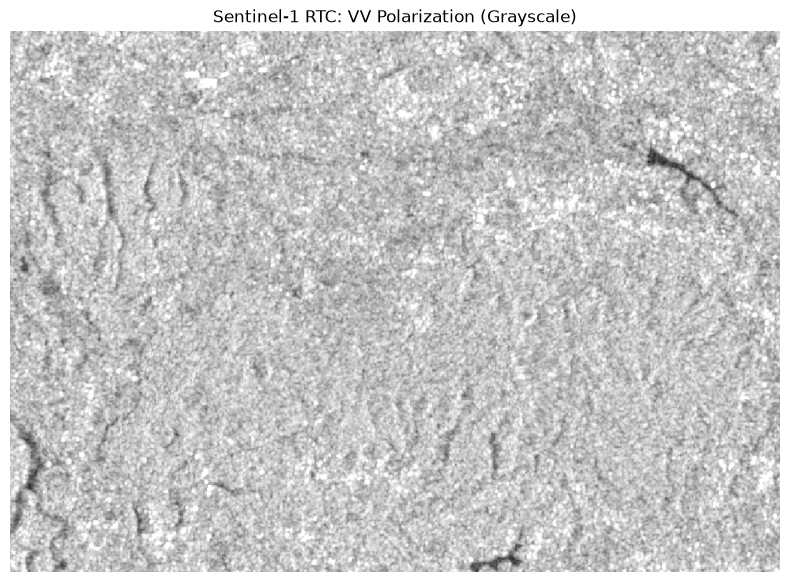

In [23]:
vv_db = 10.0 * np.log10(np.maximum(loaded_vv, 1e-5))

plt.figure(figsize=(8, 8))
plt.imshow(vv_db, cmap="gray",  vmin=-25, vmax=0)
plt.title("Sentinel-1 RTC: VV Polarization (Grayscale)")
plt.axis("off")
plt.tight_layout()
plt.show()

### **GLO-30**

In [24]:
def collect_glo30(asset_name="data"):
    glo_items = {
        "collections": ["cop-dem-glo-30"],
        "intersects": geometry,
    }
    glo_collection = tuple(stac_items(planetary_client, limit=1, **glo_items))
    asset_keys = [asset_name] if isinstance(asset_name, str) else asset_name
    return [item_records(item, asset_keys) for item in glo_collection]

In [25]:
glo30_records = collect_glo30(asset_name="data")
glo30_records

[{'id': 'Copernicus_DSM_COG_10_S07_00_E106_00_DEM',
  'datetime': '2021-04-22T00:00:00+00:00',
  'urls': {'data': 'https://elevationeuwest.blob.core.windows.net/copernicus-dem/COP30_hh/Copernicus_DSM_COG_10_S07_00_E106_00_DEM.tif?st=2026-10-07T07%3A26%3A36Z&se=2026-10-08T08%3A11%3A36Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-08T07%3A26%3A35Z&ske=2026-10-15T07%3A26%3A35Z&sks=b&skv=2025-07-05&sig=hhB2GBuDN%2BqIzRzT/AIwGO0Ovdj1wzE6CEfoSacyKzQ%3D'},
  'properties': {}}]

In [26]:
print(f"Jumlah scene tersedia: {len(glo30_records)}")
for index, record in enumerate(glo30_records, start=1):
    print(
        f"{index:02d}. {record['id']} | "
        f"image assets={sorted(record['urls'])}"
    )

Jumlah scene tersedia: 1
01. Copernicus_DSM_COG_10_S07_00_E106_00_DEM | image assets=['data']


In [27]:
glo30_scene = collect_scene_urls(glo30_records[0], ["data"])
glo30_scene

{'data': 'https://elevationeuwest.blob.core.windows.net/copernicus-dem/COP30_hh/Copernicus_DSM_COG_10_S07_00_E106_00_DEM.tif?st=2026-10-07T07%3A26%3A36Z&se=2026-10-08T08%3A11%3A36Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-08T07%3A26%3A35Z&ske=2026-10-15T07%3A26%3A35Z&sks=b&skv=2025-07-05&sig=hhB2GBuDN%2BqIzRzT/AIwGO0Ovdj1wzE6CEfoSacyKzQ%3D'}

In [28]:
loaded_glo30 = load_raster_window(glo30_scene["data"], (left, bottom, right, top), out_shape=(720, 1024))

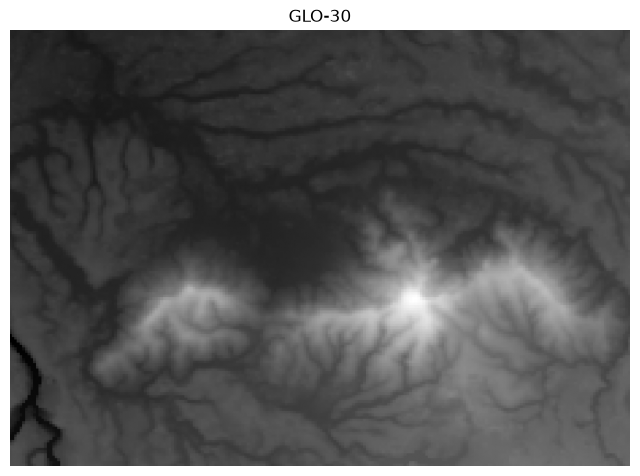

In [29]:
plt.figure(figsize=(8, 8))
plt.imshow(loaded_glo30, cmap='gray')
plt.title("GLO-30")
plt.axis("off")
plt.show()

### **Gedi**

In [30]:
class SessionWithHeaderRedirection(requests.Session):
    AUTH_HOST = "urs.earthdata.nasa.gov"

    def __init__(self, username=None, password=None):
        super().__init__()
        if username and password:
            self.auth = (username, password)

    def rebuild_auth(self, prepared_request, response):
        if "Authorization" in prepared_request.headers:
            original_host = urlparse(response.request.url).hostname
            redirect_host = urlparse(prepared_request.url).hostname
            if original_host != redirect_host and self.AUTH_HOST not in (original_host, redirect_host):
                del prepared_request.headers["Authorization"]

In [31]:
if not (username_nasa and password_nasa):
    raise ValueError("USERNAME_NASA dan PASSWORD_NASA belum terisi di file .env")

nasa_session = SessionWithHeaderRedirection(username_nasa, password_nasa)

In [32]:
gedi_l4a_collection = "GEDI_L4A_AGB_Density_V2_1_2056_2.1"
gedi_l2a_collection  = "GEDI02_A_002"

gedi_beams = [
    "BEAM0000", "BEAM0001", "BEAM0010", "BEAM0011",
    "BEAM0101", "BEAM0110", "BEAM1000", "BEAM1011",
]
gedi_l4a_keys = {
    "shot_number": "shot_number", "lon": "lon_lowestmode", "lat": "lat_lowestmode",
    "agbd": "agbd", "agbd_se": "agbd_se", "quality_flag": "l4_quality_flag",
}
gedi_l2a_keys = {
    "shot_number": "shot_number", "lon": "lon_lowestmode", "lat": "lat_lowestmode",
    "rh98": "rh",
}
AGBD_FILL = -9999.0

In [33]:
def gedi_filename(url):
    return os.path.basename(urlparse(url).path)

def gedi_granule_key(url):
    return "_".join(gedi_filename(url).split("_")[2:5])

def collect_gedi(search_client, collection_id, asset_name="data"):
    _bbox = list(_shape(geometry).bounds)
    results = tuple(stac_items(
        search_client, limit=3,
        collections=[collection_id], bbox=_bbox, datetime=datetime
    ))
    _fallbacks = [asset_name, "HDF5", "HDF", "data", "granule"]
    records = []
    for item in results:
        url = next(
            (item.assets[k].href for k in _fallbacks if k in item.assets),
            next(
                (a.href for a in item.assets.values()
                 if getattr(a, "href", "").lower().endswith((".h5", ".hdf5"))),
                next((a.href for a in item.assets.values()), "")
            )
        )
        if url:
            records.append({"id": item.id, "urls": {asset_name: url}})
    return sorted(records, key=lambda r: gedi_filename(r["urls"].get(asset_name, "")))

In [34]:
gedi_l4a_records = collect_gedi(nasa_client, gedi_l4a_collection)
gedi_l2a_records = collect_gedi(lpcloud_client, gedi_l2a_collection)
print(f"L4A records: {len(gedi_l4a_records)} | L2A records: {len(gedi_l2a_records)}")

L4A records: 3 | L2A records: 3


In [35]:
def collect_gedi_scenes(l4a_records, l2a_records, asset_name="data"):
    l2a_by_key = {
        gedi_granule_key(r["urls"][asset_name]): r["urls"][asset_name]
        for r in l2a_records if r["urls"].get(asset_name)
    }
    scenes = []
    for r in l4a_records:
        url = r["urls"].get(asset_name, "")
        if url and gedi_granule_key(url) in l2a_by_key:
            scenes.append({"id": gedi_filename(url), "l4a": url, "l2a": l2a_by_key[gedi_granule_key(url)]})
    return scenes

gedi_scenes = collect_gedi_scenes(gedi_l4a_records, gedi_l2a_records)
print(f"Scene L4A-L2A cocok: {len(gedi_scenes)}")
for i, s in enumerate(gedi_scenes): print(f"  {i}: {s['id']}")


Scene L4A-L2A cocok: 3
  0: GEDI04_A_2025016184431_O34537_04_T01712_02_004_01_V002.h5
  1: GEDI04_A_2025127224257_O36261_04_T05828_02_004_01_V002.h5
  2: GEDI04_A_2025166073119_O36856_04_T08674_02_004_01_V002.h5


In [36]:
gedi_scene = gedi_scenes[1]
gedi_scene

{'id': 'GEDI04_A_2025127224257_O36261_04_T05828_02_004_01_V002.h5',
 'l4a': 'https://data.ornldaac.earthdata.nasa.gov/protected/gedi/GEDI_L4A_AGB_Density_V2_1/data/GEDI04_A_2025127224257_O36261_04_T05828_02_004_01_V002.h5',
 'l2a': 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/GEDI02_A.002/GEDI02_A_2025127224257_O36261_04_T05828_02_004_02_V002/GEDI02_A_2025127224257_O36261_04_T05828_02_004_02_V002.h5'}

In [37]:
def read_gedi_granule(session, asset_url, keys, bounds):
    left, bottom, right, top = bounds
    parts = {name: [] for name in keys}
    with tempfile.TemporaryDirectory() as tmp:
        h5_path = os.path.join(tmp, "gedi.h5")
        with session.get(asset_url, stream=True, timeout=120) as resp, open(h5_path, "wb") as f:
            resp.raise_for_status()
            for chunk in resp.iter_content(4 * 1024 * 1024): f.write(chunk)
        with h5py.File(h5_path, "r") as h5:
            for beam in filter(h5.__contains__, gedi_beams):
                data = {name: h5[beam][ds][:] for name, ds in keys.items()}
                data = {k: v[:, 98] if v.ndim == 2 else v for k, v in data.items()}
                mask = (data["lon"] >= left) & (data["lon"] <= right) & (data["lat"] >= bottom) & (data["lat"] <= top)
                for name in keys: parts[name].append(data[name][mask])
    return pd.DataFrame({k: np.concatenate(v) if v else np.array([]) for k, v in parts.items()})

def load_gedi_points(scene, bounds, area_geometry=None):
    try:
        l4a = read_gedi_granule(nasa_session, scene["l4a"], gedi_l4a_keys, bounds)
        l2a = read_gedi_granule(nasa_session, scene["l2a"], gedi_l2a_keys, bounds)
        pts = l4a.merge(l2a[["shot_number", "rh98"]], on="shot_number", how="left")
        if area_geometry is not None and len(pts):
            area = shape(area_geometry)
            pts = pts[shapely.contains_xy(area, pts["lon"].to_numpy(), pts["lat"].to_numpy())]
        return {col: pts[col].to_numpy() for col in pts}
    except Exception as e:
        print(f"Peringatan: Gagal memuat data GEDI granule ({e})")
        return None

In [38]:
loaded_gedi = load_gedi_points(gedi_scene, (left, bottom, right, top), area_geometry=geometry)

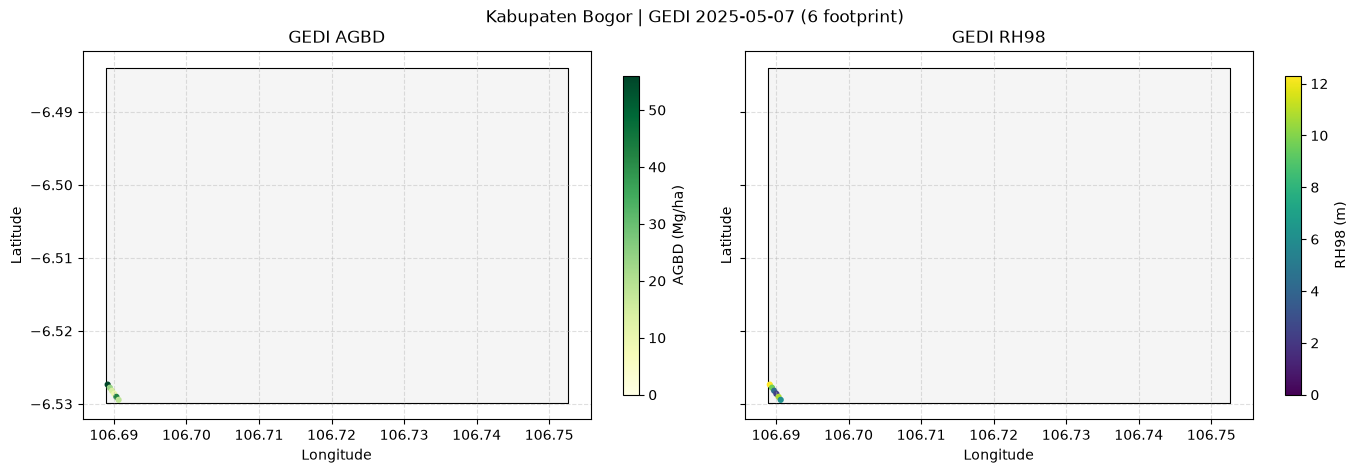

In [39]:
valid = (
    (loaded_gedi["quality_flag"] == 1) &
    (loaded_gedi["agbd"] > AGBD_FILL) &
    np.isfinite(loaded_gedi["agbd"])
)

if not valid.any():
    valid = (loaded_gedi["agbd"] > AGBD_FILL) & np.isfinite(loaded_gedi["agbd"])

acq_date = pd.to_datetime(gedi_scene["id"].split("_")[2][:7], format="%Y%j").date()
lon_v, lat_v = loaded_gedi["lon"][valid], loaded_gedi["lat"][valid]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
panels = [
    ("agbd", "AGBD (Mg/ha)", "YlGn"),
    ("rh98", "RH98 (m)",     "viridis"),
]
aoi_outline = gpd.GeoSeries([aoi], crs="EPSG:4326")
for ax, (key, label, cmap) in zip(axes, panels):
    aoi_outline.plot(ax=ax, facecolor="whitesmoke", edgecolor="black", linewidth=0.8)
    values = loaded_gedi[key][valid]
    mask   = np.isfinite(values)
    sc = ax.scatter(lon_v[mask], lat_v[mask], c=values[mask], cmap=cmap,
                    s=12, vmin=0, vmax=np.nanpercentile(values[mask], 98))
    fig.colorbar(sc, ax=ax, shrink=0.5, label=label)
    ax.set(title=f"GEDI {key.upper()}", xlabel="Longitude", ylabel="Latitude")
    ax.grid(ls="--", alpha=0.4)
fig.suptitle(f"Kabupaten Bogor | GEDI {acq_date} ({valid.sum()} footprint)", y=0.8)
plt.tight_layout()
plt.show()

### **Dynamic Word**

In [40]:
dynamic_world_bands = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12"]
dynamic_world_model_path = Path("models/dynamicword/forward")
dynamic_world_model = tf.saved_model.load(str(dynamic_world_model_path))

In [41]:
norm_percentiles = np.array([
    [1.7417268007636313, 2.023298706048351],
    [1.7261204997060209, 2.038905204308012],
    [1.6798346251414997, 2.179592821578937],
    [1.7734969472909623, 2.2890068333026603],
    [2.289154079164943, 2.6171674549378166],
    [2.382939712192371, 2.773418590375327],
    [2.3828939530384052, 2.7578332604178284],
    [2.1952484264967844, 2.789092484314204],
    [1.554812948247501, 2.4140534947492487],
], dtype="float32")

def normalize_dynamic_world(image):
    image = np.nan_to_num(image.astype("float32"), nan=0.0, posinf=0.0, neginf=0.0)
    image = np.log(image * 0.005 + 1.0)
    image = (image - norm_percentiles[:, 0]) / norm_percentiles[:, 1]
    image = np.exp(image * 5.0 - 1.0)
    return image / (image + 1.0)

In [42]:
def load_dynamic_world_input(scene, bounds, out_shape=(512, 512)):
    bands = [
        load_raster_window(scene[band], bounds, out_shape=out_shape).filled(np.nan)
        for band in dynamic_world_bands
    ]
    return np.stack(bands, axis=-1)

def predict_dynamic_world(image):
    inputs = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)
    logits = dynamic_world_model(inputs)
    return tf.nn.softmax(logits, axis=-1).numpy()[0]

def dynamic_world_record(scene, bounds, out_shape=(512, 512)):
    image = load_dynamic_world_input(scene, bounds, out_shape=out_shape)
    probabilities = predict_dynamic_world(normalize_dynamic_world(image))
    return {
        "id": scene["id"],
        "datetime": scene.get("datetime"),
        "probabilities": probabilities,
        "image": image,
    }

In [43]:
def collect_dynamic_world(records, bounds, scene_indices=None, out_shape=(512, 512)):
    selected_indices = range(len(records)) if scene_indices is None else scene_indices
    dynamic_world_records = []
    for scene_index in selected_indices:
        selected = records[scene_index]
        scene = collect_scene_urls(selected, dynamic_world_bands)
        scene["id"] = selected["id"]
        scene["datetime"] = selected.get("datetime")
        dynamic_world_records.append(dynamic_world_record(scene, bounds, out_shape=out_shape))
    return dynamic_world_records

In [44]:
s2_records = collect_sentinel2(
    bands=["visual", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12"],
    cloud_cover=10,
)
dw_records = collect_dynamic_world(s2_records, (left, bottom, right, top), scene_indices=[0])

In [45]:
dw_scene = dw_records[0]
dw_scene.keys()

dict_keys(['id', 'datetime', 'probabilities', 'image'])

In [46]:
print(f"Dynamic World scene: {dw_scene['id']} | datetime: {dw_scene.get('datetime', 'n/a')}")
for i, class_name in enumerate(["Water", "Trees", "Grass", "Flooded Vegetation", "Crops", "Shrub and Scrub", "Built", "Bare", "Snow and Ice"]):
    print(f"  {i:02d}. {class_name} | probability range: {dw_scene['probabilities'][..., i].min():.3f} - {dw_scene['probabilities'][..., i].max():.3f}")

Dynamic World scene: S2B_MSIL2A_20250826T025529_R032_T48MXT_20250826T063629 | datetime: 2025-08-26T02:55:29.024000+00:00
  00. Water | probability range: 0.011 - 0.711
  01. Trees | probability range: 0.017 - 0.436
  02. Grass | probability range: 0.022 - 0.530
  03. Flooded Vegetation | probability range: 0.020 - 0.523
  04. Crops | probability range: 0.023 - 0.689
  05. Shrub and Scrub | probability range: 0.019 - 0.271
  06. Built | probability range: 0.028 - 0.793
  07. Bare | probability range: 0.019 - 0.411
  08. Snow and Ice | probability range: 0.022 - 0.145


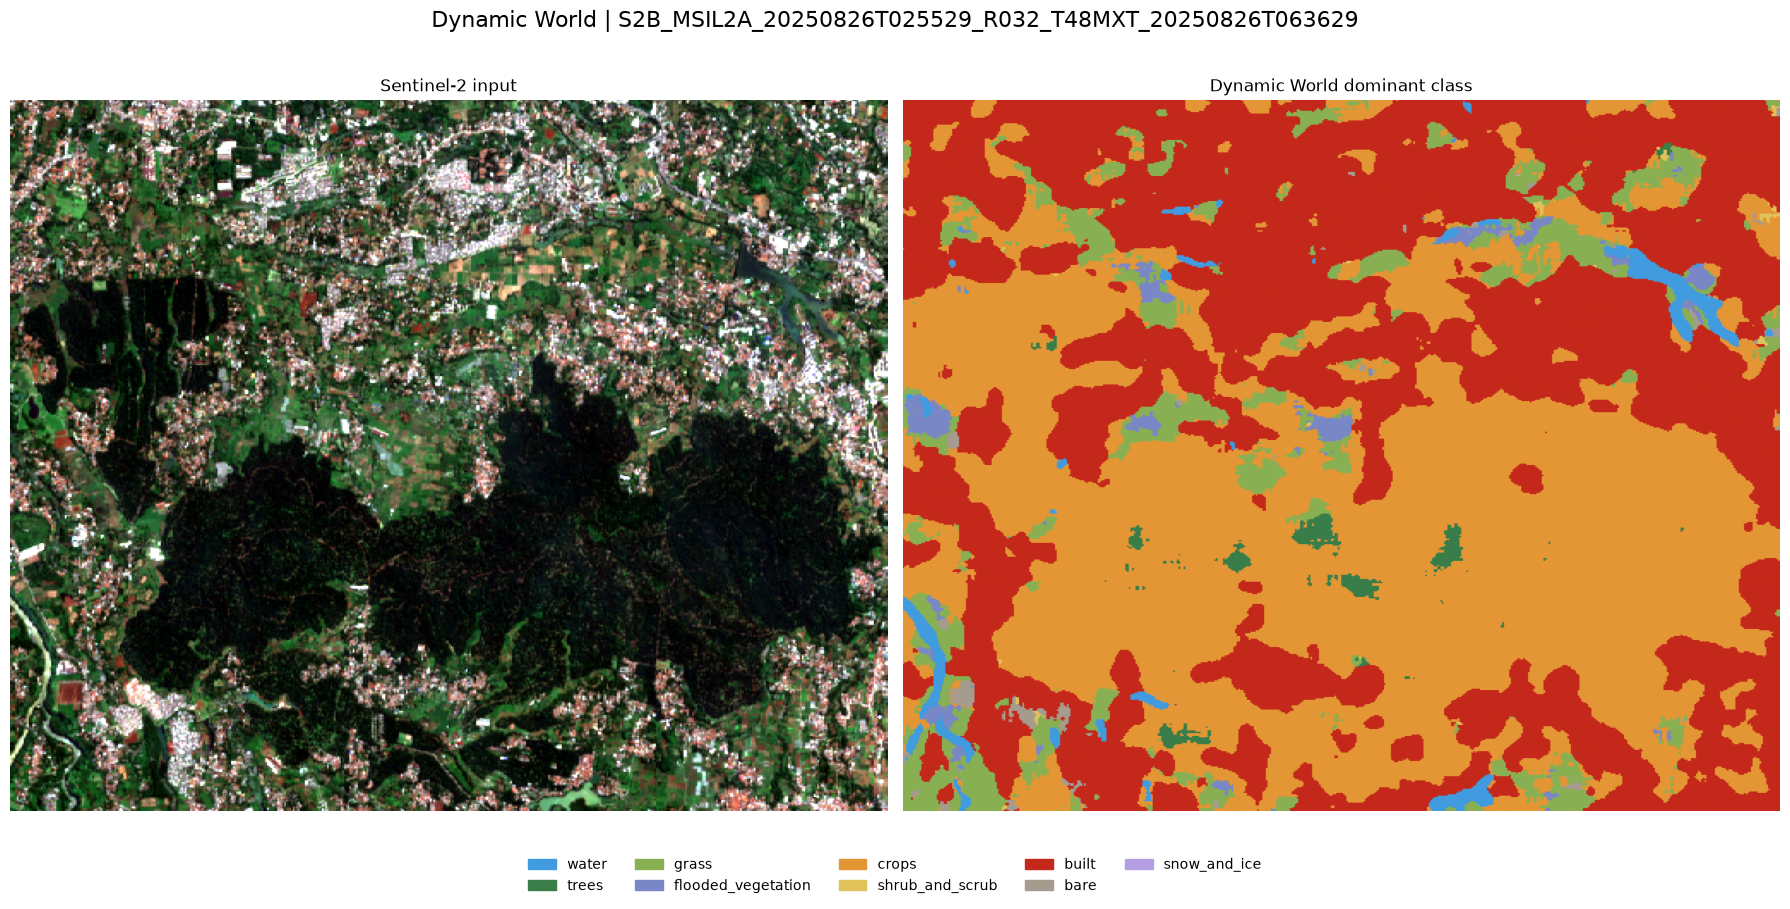

In [47]:
class_names = ["water", "trees", "grass", "flooded_vegetation", "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"]
class_colors = ["#419bdf", "#397d49", "#88b053", "#7a87c6", "#e49635", "#dfc35a", "#c4281b", "#a59b8f", "#b39fe1"]

image = dw_scene["image"]
rgb = image[..., [2, 1, 0]].copy()
for channel in range(rgb.shape[-1]):
    low, high = np.nanpercentile(rgb[..., channel], (2, 98))
    rgb[..., channel] = np.clip((rgb[..., channel] - low) / max(high - low, 1e-6), 0, 1)
rgb = np.nan_to_num(rgb)

probabilities = dw_scene["probabilities"]
class_map = probabilities.argmax(axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)
axes[0].imshow(rgb, aspect="auto")
axes[0].set_title("Sentinel-2 input")
axes[1].imshow(class_map, cmap=plt.matplotlib.colors.ListedColormap(class_colors), vmin=-0.5, vmax=8.5, aspect="auto")
axes[1].set_title("Dynamic World dominant class")
for axis in axes:
    axis.set_axis_off()

legend_handles = [plt.matplotlib.patches.Patch(color=color, label=name) for name, color in zip(class_names, class_colors)]
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=5, frameon=False)
fig.suptitle(f"Dynamic World | {dw_scene['id']}", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# **Data collection**

Tahap ini mengunduh data AOI dari semua sumber dan menyimpannya sebagai file lokal.

- Menetapkan jumlah scene (3), ukuran output (512x512), dan daftar band per dataset
- Menyimpan tiap scene sebagai GeoTIFF terpotong AOI, dan melewati file yang sudah ada
- Menyimpan probabilitas Dynamic World sebagai GeoTIFF 9 band
- Menyimpan titik GEDI valid sebagai CSV
- Memakai file lokal jika semua dataset sudah ada, jika belum maka diunduh

In [48]:
COLLECTION_TOP_K = 3
COLLECTION_OUT_SHAPE = (512, 512)
COLLECTION_BANDS = {
    "sentinel02": ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12"],
    "sentinel1": ["vv", "vh"],
    "glo30": ["data"],
    "gedil4a": ["agbd", "agbd_se", "quality_flag", "rh98"],
    "dynamic_world": ["water", "trees", "grass", "flooded_vegetation", "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"]
}

In [49]:
def collection_date(scene):
    value = scene.get("datetime") or scene.get("properties", {}).get("datetime")
    return pd.Timestamp(value).strftime("%Y%m%d") if value else "nodate"

def collection_scene_token(scene_id):
    token = "".join(c if c.isalnum() else "_" for c in str(scene_id))
    return token.strip("_")[:80] or "scene"


In [50]:
def write_dataset_scene_tif(dataset_name, scene, bands, output_dir="data"):
    valid_bands = [b for b in bands if b in scene.get("urls", {})]
    if not valid_bands:
        return None
    dataset_dir = output_dir / dataset_name
    dataset_dir.mkdir(parents=True, exist_ok=True)
    filename = f"{dataset_name}_{collection_date(scene)}_{collection_scene_token(scene['id'])}.tif"
    output_path = dataset_dir / filename
    if output_path.exists() and output_path.stat().st_size > 0:
        return output_path

    ref_url = scene["urls"][valid_bands[0]]
    with rasterio.open(ref_url) as ref_source:
        bounds = transform_bounds("EPSG:4326", ref_source.crs, left, bottom, right, top)
        ref_window = from_bounds(*bounds, transform=ref_source.transform).round_offsets().round_lengths()
        height, width = int(ref_window.height), int(ref_window.width)
        nodata = ref_source.nodata if ref_source.nodata is not None else -9999.0
        profile = ref_source.profile.copy()
        profile.update(
            driver="GTiff",
            height=height,
            width=width,
            count=len(valid_bands),
            dtype="float32",
            nodata=nodata,
            transform=ref_source.window_transform(ref_window),
            compress="deflate",
            predictor=2,
        )

    # Ambil image dan tulis band secara bertahap
    with rasterio.open(output_path, "w", **profile) as destination:
        for idx, band in enumerate(valid_bands, start=1):
            with rasterio.open(scene["urls"][band]) as source:
                b_bounds = transform_bounds("EPSG:4326", source.crs, left, bottom, right, top)
                b_window = from_bounds(*b_bounds, transform=source.transform).round_offsets().round_lengths()
                data = source.read(1, window=b_window, out_shape=(height, width), masked=True).astype("float32")
                b_nodata = source.nodata if source.nodata is not None else nodata
                destination.write(data.filled(b_nodata), idx)
                destination.set_band_description(idx, band)
    return output_path


def collect_raster_dataset(dataset_name, records, bands, max_scenes=COLLECTION_TOP_K):
    outputs = []
    for scene in records[:max_scenes]:
        path = write_dataset_scene_tif(dataset_name, scene, bands)
        if path:
            outputs.append(path)
    return outputs

In [51]:
def write_dynamic_world_scene(scene, output_dir="data"):
    DW_CLASSES = ["water", "trees", "grass", "flooded_vegetation", "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"]
    source_url = scene.get("urls", {}).get("B02")
    if not source_url or any(band not in scene.get("urls", {}) for band in dynamic_world_bands):
        return None
    dataset_dir = output_dir / "dynamic_world"
    dataset_dir.mkdir(parents=True, exist_ok=True)
    output_path = dataset_dir / f"dynamic_world_{collection_date(scene)}_{collection_scene_token(scene['id'])}.tif"
    if output_path.exists() and output_path.stat().st_size > 0:
        return output_path

    with rasterio.open(source_url) as source:
        bounds = transform_bounds("EPSG:4326", source.crs, left, bottom, right, top)
        window = from_bounds(*bounds, transform=source.transform).round_offsets().round_lengths()
        # Ambil band citra secara bertahap
        image = np.stack([
            load_raster_window(scene["urls"][band], (left, bottom, right, top), out_shape=COLLECTION_OUT_SHAPE).filled(np.nan)
            for band in dynamic_world_bands
        ], axis=-1)
        probabilities = predict_dynamic_world(normalize_dynamic_world(image))
        transform = source.window_transform(window) * Affine.scale(
            window.width / COLLECTION_OUT_SHAPE[1],
            window.height / COLLECTION_OUT_SHAPE[0],
        )
        profile = source.profile.copy()
        profile.update(
            driver="GTiff",
            height=probabilities.shape[0],
            width=probabilities.shape[1],
            count=len(9),
            dtype="float32",
            nodata=-9999.0,
            transform=transform,
            compress="deflate",
        )
        with rasterio.open(output_path, "w", **profile) as destination:
            for index, class_name in enumerate(DW_CLASSES, start=1):
                destination.write(probabilities[..., index - 1].astype("float32"), index)
                destination.set_band_description(index, class_name)
    return output_path


def collect_dynamic_world_dataset(records, max_scenes=COLLECTION_TOP_K):
    outputs = []
    for scene in records[:max_scenes]:
        path = write_dynamic_world_scene(scene)
        if path:
            outputs.append(path)
    return outputs

In [52]:
def write_gedi_scene_table(scene, output_dir="data"):
    output_path = output_dir / "gedil4a" / f"gedil4a_{collection_date(scene)}_{collection_scene_token(scene['id'])}.csv"
    if output_path.exists() and output_path.stat().st_size > 0:
        return output_path
    points = load_gedi_points(scene, (left, bottom, right, top), area_geometry=geometry)
    if not points and "loaded_gedi" in globals():
        points = globals()["loaded_gedi"]
    if not points:
        return None
    df = pd.DataFrame(points)
    valid = (df["quality_flag"] == 1) & (df["agbd"] > AGBD_FILL) & np.isfinite(df["agbd"])
    df_valid = df[valid if valid.any() else (df["agbd"] > AGBD_FILL)].copy()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df_valid.to_csv(output_path, index=False)
    return output_path

def collect_gedi_l4a_dataset(scenes, max_scenes=COLLECTION_TOP_K):
    return [p for s in scenes[:max_scenes] if (p := write_gedi_scene_table(s))]

In [53]:
def download_images():
    files = {}
    print("[1/5] Sentinel-2")
    s2_records = collect_sentinel2(COLLECTION_BANDS["sentinel02"], cloud_cover=10, max_scenes=COLLECTION_TOP_K)
    files["sentinel02"] = collect_raster_dataset("sentinel02", s2_records, COLLECTION_BANDS["sentinel02"])
    print(f"sentinel02: {len(files['sentinel02'])} GeoTIFF")

    print("[2/5] Sentinel-1")
    s1_records = collect_sentinel1(COLLECTION_BANDS["sentinel1"], orbit_direction="descending", max_scenes=COLLECTION_TOP_K)
    files["sentinel1"] = collect_raster_dataset("sentinel1", s1_records, COLLECTION_BANDS["sentinel1"])
    print(f"sentinel1: {len(files['sentinel1'])} GeoTIFF")

    print("[3/5] GLO-30")
    glo30_records = collect_glo30(asset_name=COLLECTION_BANDS["glo30"][0])
    files["glo30"] = collect_raster_dataset("glo30", glo30_records, COLLECTION_BANDS["glo30"], max_scenes=1)
    print(f"glo30: {len(files['glo30'])} GeoTIFF")

    print("[4/5] GEDI L4A/L2A")
    scenes = gedi_scenes if "gedi_scenes" in globals() and gedi_scenes else [gedi_scene]
    files["gedil4a"] = collect_gedi_l4a_dataset(scenes)
    print(f"gedil4a: {len(files['gedil4a'])} Footprint Table (CSV)")

    print("[5/5] Dynamic World")
    files["dynamic_world"] = collect_dynamic_world_dataset(s2_records)
    print(f"dynamic_world: {len(files['dynamic_world'])} GeoTIFF")
    return files

In [54]:
def check_all_datasets_downloaded(base_dir="data", required_datasets=("sentinel02", "sentinel1", "glo30", "gedil4a", "dynamic_world")):
    for ds in required_datasets:
        ds_dir = Path(base_dir) / ds
        if not ds_dir.is_dir() or not any(ds_dir.iterdir()):
            return False
    return True

written_files = {}
if check_all_datasets_downloaded():
    print("All datasets have been downloaded:")
    for ds in ["sentinel02", "sentinel1", "glo30", "gedil4a", "dynamic_world"]:
        written_files[ds] = sorted(list((Path("data") / ds).glob("*.*")))
        print(f"{ds}: {len(written_files[ds])} file ditemukan di lokal")
else:
    print("Few datasets incomplete")
    written_files = download_images()

All datasets have been downloaded:
sentinel02: 3 file ditemukan di lokal
sentinel1: 3 file ditemukan di lokal
glo30: 1 file ditemukan di lokal
gedil4a: 3 file ditemukan di lokal
dynamic_world: 3 file ditemukan di lokal


In [55]:
print("\n ====== Summary of Downloaded Files ======")
for dataset, paths in written_files.items():
    print(f"{dataset} ({len(paths)} file):")
    for p in paths:
        print(f"  - {p}")


 ====== Summary of Downloaded Files ======
sentinel02 (3 file):
  - data\sentinel02\sentinel02_20250801_S2C_MSIL2A_20250801T025611_R032_T48MXT_20250801T064714.tif
  - data\sentinel02\sentinel02_20250816_S2B_MSIL2A_20250816T025529_R032_T48MXT_20250816T063937.tif
  - data\sentinel02\sentinel02_20250826_S2B_MSIL2A_20250826T025529_R032_T48MXT_20250826T063629.tif
sentinel1 (3 file):
  - data\sentinel1\sentinel1_20250519_S1A_IW_GRDH_1SDV_20250519T223405_20250519T223432_059269_075AEA_rtc.tif
  - data\sentinel1\sentinel1_20250612_S1A_IW_GRDH_1SDV_20250612T223404_20250612T223431_059619_0766F6_rtc.tif
  - data\sentinel1\sentinel1_20250811_S1A_IW_GRDH_1SDV_20250811T223402_20250811T223429_060494_rtc.tif
glo30 (1 file):
  - data\glo30\glo30_20210422_Copernicus_DSM_COG_10_S07_00_E106_00_DEM.tif
gedil4a (3 file):
  - data\gedil4a\gedil4a_nodate_GEDI04_A_2025016184431_O34537_04_T01712_02_004_01_V002_h5.csv
  - data\gedil4a\gedil4a_nodate_GEDI04_A_2025127224257_O36261_04_T05828_02_004_01_V002_h5.csv
 

# **Data Preprocessing**

Tahap ini menyeragamkan semua dataset ke satu grid 30 m dan mengekstrak fitur input model.

- Membuat grid target UTM 48S dari batas AOI
- Mereproyeksi semua raster ke grid tersebut
- **Sentinel-2:** komposit median, band reflektansi, dan indeks vegetasi (DVI, EVI, GNDVI, NDVI, RVI)
- **Sentinel-1:** VV dan VH dalam dB, serta tekstur GLCM (cache `.npz`)
- **GLO-30:** elevasi, slope, dan aspect
- **Dynamic World:** rata-rata probabilitas tiap kelas
- Menggabungkan semua fitur ke `all_features`

In [56]:
PREPROCESS_CACHE_FILE = Path("data/preprocessed/s1_features_cache.npz")
grid_l, grid_b, grid_r, grid_t = transform_bounds("EPSG:4326", crs, *aoi.bounds)
GRID_WIDTH = int(np.ceil((grid_r - grid_l) / scale))
GRID_HEIGHT = int(np.ceil((grid_t - grid_b) / scale))
GRID_TRANSFORM = from_origin(grid_l, grid_t, scale, scale)
GRID_SHAPE = (GRID_HEIGHT, GRID_WIDTH)

In [57]:
def reproject_to_grid(src_path, band_index=1, resampling=Resampling.bilinear):
    with rasterio.open(src_path) as src:
        dst = np.full(GRID_SHAPE, np.nan, dtype="float32")
        reproject(
            source=rasterio.band(src, band_index), destination=dst,
            src_transform=src.transform, src_crs=src.crs, src_nodata=src.nodata,
            dst_transform=GRID_TRANSFORM, dst_crs=crs, dst_nodata=np.nan,
            resampling=resampling,
        )
        return dst

def safe_divide(num, den):
    return np.divide(num, den, out=np.full_like(num, np.nan, dtype="float32"), where=np.abs(den) > 1e-6)

### **Sentinel-2**

In [58]:
def preprocess_sentinel2_features(s2_files):
    bands = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12"]
    stacks = {b: [reproject_to_grid(f, i) for f in s2_files] for i, b in enumerate(bands, 1)}
    comp = {b: np.nanmedian(np.stack(stacks[b]), axis=0).astype("float32") for b in bands}
    
    scale_refl = lambda x: x * 0.0001 if np.nanmedian(x) > 10 else x
    b2, b3, b4, b8 = scale_refl(comp["B02"]), scale_refl(comp["B03"]), scale_refl(comp["B04"]), scale_refl(comp["B08"])
    
    scale_dn = lambda x: x * 10000.0 if np.nanmedian(x) < 10 else x
    b5, b6, b11, b12 = scale_dn(comp["B05"]), scale_dn(comp["B06"]), scale_dn(comp["B11"]), scale_dn(comp["B12"])
    
    return {
        "B2": b2, "B3": b3, "B4": b4, "B8": b8,
        "B5": b5, "B6": b6, "B11": b11, "B12": b12,
        "DVI": b8 - b4,
        "EVI": 2.5 * safe_divide(b8 - b4, b8 + 6.0 * b4 - 7.5 * b2 + 1.0),
        "GNDVI": safe_divide(b8 - b3, b8 + b3),
        "NDVI": safe_divide(b8 - b4, b8 + b4),
        "RVI": safe_divide(b8, b4),
    }

In [59]:

features_s2 = preprocess_sentinel2_features(written_files["sentinel02"])

### **Sentinel-1**

In [60]:
def quantize_texture(img, low=-25, high=0):
    scaled = (np.nan_to_num(img, nan=low) - low) / max(high - low, 1e-6)
    return np.clip(scaled * 63, 0, 63).astype("uint8")

def glcm_features(img, window=5):
    rad = window // 2
    padded = np.pad(quantize_texture(img), rad, mode="edge")
    h, w = img.shape
    res = {k: np.full((h, w), np.nan, dtype="float32") for k in ("contrast", "corr", "ent")}
    dist, angles = [1], [0, np.pi/4, np.pi/2, 3*np.pi/4]
    for r in range(h):
        for c in range(w):
            m = graycomatrix(padded[r:r+window, c:c+window], dist, angles, levels=64, symmetric=True, normed=True)
            p = m.astype("float32")
            res["contrast"][r, c] = np.nanmean(graycoprops(m, "contrast"))
            res["corr"][r, c] = np.nanmean(graycoprops(m, "correlation"))
            res["ent"][r, c] = np.nanmean(-(p * np.log2(np.maximum(p, 1e-12))).sum(axis=(0, 1, 2)))
    return res

In [61]:
def preprocess_sentinel1_features(s1_files, cache_file=PREPROCESS_CACHE_FILE):
    if cache_file.exists():
        loaded = np.load(cache_file)
        return {k: loaded[k] for k in loaded.files}
    vv = np.nanmedian(np.stack([reproject_to_grid(f, 1) for f in s1_files]), axis=0)
    vh = np.nanmedian(np.stack([reproject_to_grid(f, 2) for f in s1_files]), axis=0)
    vv_db = (10.0 * np.log10(np.maximum(vv, 1e-5)) if np.nanmedian(vv) > 0 else vv).astype("float32")
    vh_db = (10.0 * np.log10(np.maximum(vh, 1e-5)) if np.nanmedian(vh) > 0 else vh).astype("float32")
    vv_tex, vh_tex = glcm_features(vv_db), glcm_features(vh_db)
    out = {
        "VV": vv_db, "VV_contrast": vv_tex["contrast"], "VV_corr": vv_tex["corr"], "VV_ent": vv_tex["ent"],
        "VH": vh_db, "VH_contrast": vh_tex["contrast"], "VH_corr": vh_tex["corr"], "VH_ent": vh_tex["ent"],
    }
    np.savez_compressed(cache_file, **out)
    return out

In [62]:
features_s1 = preprocess_sentinel1_features(written_files["sentinel1"])

### **GLO-30**

In [63]:
def preprocess_dem_features(dem_files):
    dem = reproject_to_grid(dem_files[0], 1)
    gy, gx = np.gradient(dem, scale)
    slope = np.degrees(np.arctan(np.hypot(gx, gy))).astype("float32")
    aspect = np.mod(np.degrees(np.arctan2(-gx, gy)), 360.0).astype("float32")
    return {"dem": dem, "slope": slope, "aspect": aspect}

In [64]:
features_dem = preprocess_dem_features(written_files["glo30"])

### **Dynamic Word**

In [65]:
def preprocess_dynamic_world_features(dw_files):
    DW_CLASSES = ["water", "trees", "grass", "flooded_vegetation", "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"]
    stacks = {c: [reproject_to_grid(f, i) for f in dw_files] for i, c in enumerate(DW_CLASSES, 1)}
    return {c: np.nanmean(np.stack(stacks[c]), axis=0).astype("float32") for c in DW_CLASSES}

In [66]:
features_dw = preprocess_dynamic_world_features(written_files["dynamic_world"])

### **Concatenated Dataset**

In [67]:
all_features = {**features_s2, **features_s1, **features_dem, **features_dw}

In [68]:
pd.DataFrame({
    "Dataset": ["Sentinel-2", "Sentinel-1", "GLO-30", "Dynamic Word"],
    "Jumlah": [len(features_s2.keys()), len(features_s1.keys()), len(features_dem.keys()), len(features_dw)]
})

,Dataset,Jumlah
0,Sentinel-2,13
1,Sentinel-1,8
2,GLO-30,3
3,Dynamic Word,9


# **Inference**

Tahap ini memprediksi AGBD per piksel dengan model Random Forest, lalu membatasi hasilnya pada area vegetasi.

- Memuat model dan mengambil urutan fitur dari `feature_names_in_`
- Menyusun matriks fitur dan menandai piksel valid
- Memprediksi AGBD pada piksel valid dan menyusunnya menjadi peta 2D
- Memberi nilai 0 pada area non-vegetasi berdasarkan Dynamic World
- Menampilkan statistik dan peta AGBD

In [69]:
OUTPUT_DIR = "data/inference"
AGBD_OUTPUT_TIF = f"{OUTPUT_DIR}/agbd_prediction_{datetime.replace("/", "_").replace(":", "")}.tif"

with open("models/randomforest.pkl", "rb") as f:
    rf_model = pickle.load(f)
    
rf_features = list(rf_model.feature_names_in_)

In [70]:
feature_df = pd.DataFrame({col: all_features[col].reshape(-1) for col in rf_features})
valid_pixels_mask = np.isfinite(feature_df.to_numpy()).all(axis=1)

features_matrix = np.full(feature_df.shape, np.nan, dtype="float32")
features_matrix[valid_pixels_mask] = feature_df.loc[valid_pixels_mask].to_numpy(dtype="float32")

print(f"Shape of features_matrix : {feature_df.shape} ({GRID_HEIGHT}x{GRID_WIDTH} piksel)")
print(f"Count of valid pixels    : {valid_pixels_mask.sum()} / {len(valid_pixels_mask)} ({valid_pixels_mask.sum()/len(valid_pixels_mask)*100:.1f}%)")

Shape of features_matrix : (40120, 33) (170x236 piksel)
Count of valid pixels    : 39108 / 40120 (97.5%)


In [71]:
def predict_agbd_spatial(features, valid_mask, grid_shape, model=None):
    rf_model = model
    agbd_map = np.full(len(valid_mask), np.nan, dtype="float32")
    if valid_mask.any():
        agbd_map[valid_mask] = rf_model.predict(features[valid_mask]).astype("float32")
    return agbd_map.reshape(grid_shape)

agbd_map = predict_agbd_spatial(features_matrix, valid_pixels_mask, GRID_SHAPE, rf_model)

In [72]:
valid_values = agbd_map[np.isfinite(agbd_map)]
if len(valid_values) > 0:
    print(f"Statistik AGBD (Mg/ha): Min={valid_values.min():.2f}, Mean={valid_values.mean():.2f}, Max={valid_values.max():.2f}")

Statistik AGBD (Mg/ha): Min=68.67, Mean=105.45, Max=225.15


In [73]:
def mask_agbd_by_landcover(agbd_map, landcover_path):
    class_names = ["water", "trees", "grass", "flooded_vegetation", "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"]
    vegetation = {"trees", "grass", "flooded_vegetation", "crops", "shrub_and_scrub"}
    vegetation_ids = [i for i, name in enumerate(class_names) if name in vegetation]

    with rasterio.open(landcover_path) as src:
        data = src.read(out_shape=(src.count, *agbd_map.shape), resampling=Resampling.nearest).astype("float32")

    if data.shape[0] == 1:
        valid = np.isfinite(data[0])
        labels = np.where(valid, data[0], -1).astype("int16")
    else:
        valid = np.isfinite(data).all(axis=0)
        labels = data.argmax(axis=0)

    keep = valid & np.isin(labels, vegetation_ids)
    return np.where(keep, agbd_map, 0.0).astype("float32")

In [ ]:
def plot_agbd_map(agbd_map, aoi_geom=aoi, transform=GRID_TRANSFORM, crs=crs, vmin=50, vmax=200, cmap="plasma"):
    h, w = agbd_map.shape
    left, bottom, right, top = array_bounds(h, w, transform)
    
    fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
    im = ax.imshow(agbd_map, extent=(left, right, bottom, top), origin="upper", cmap=cmap,
                   vmin=vmin, vmax=vmax, interpolation="bicubic")
    
    cbar = fig.colorbar(im, ax=ax, shrink=0.7, fraction=0.046, pad=0.04)
    cbar.set_label("AGBD (Mg/ha)", fontsize=11, fontweight="bold")
    ax.set_title(f"Peta Prediksi Aboveground Biomass Density (AGBD) | 2025", fontsize=12, fontweight="bold")
    ax.set_xlabel("Easting (m, UTM 48S)", fontsize=10)
    ax.set_ylabel("Northing (m, UTM 48S)", fontsize=10)
    ax.legend(loc="upper right")
    fig.savefig("assets/prediction.png", dpi=300, bbox_inches="tight")
    plt.show()

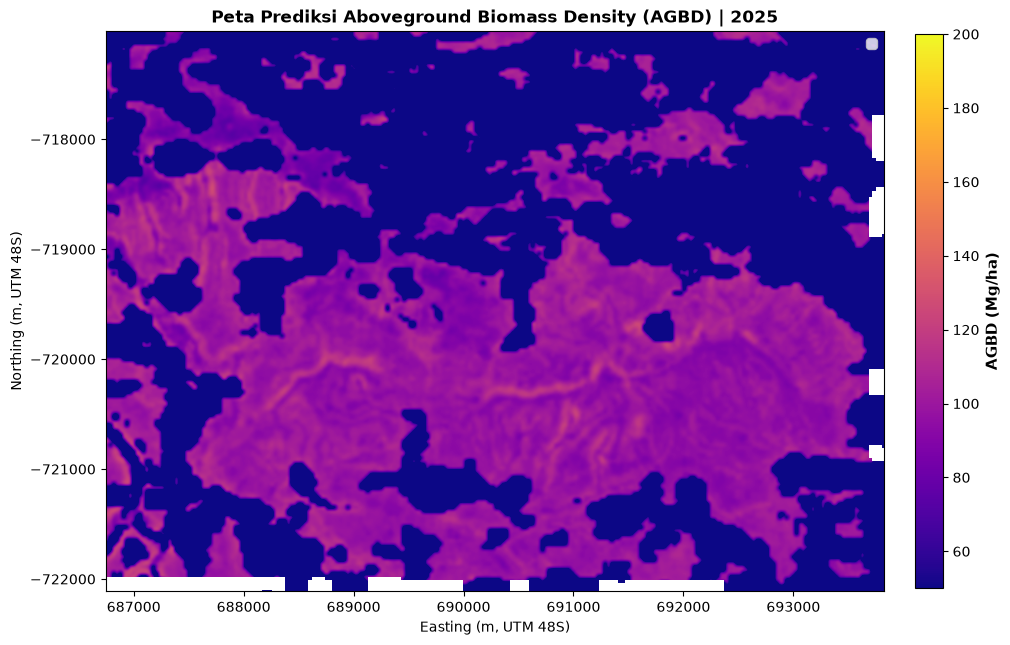

In [75]:
mask_agbd_map = mask_agbd_by_landcover(agbd_map, "data/dynamic_world/dynamic_world_20250801_S2C_MSIL2A_20250801T025611_R032_T48MXT_20250801T064714.tif")
plot_agbd_map(mask_agbd_map, cmap="plasma")

# **Save Map**

Tahap ini menyimpan peta prediksi AGBD sebagai GeoTIFF berreferensi geografis.

- Menulis peta 2D ke GeoTIFF satu band (float32, terkompresi)
- Menyimpan CRS, transform, dan deskripsi band `AGBD_Mg_ha`
- Mencetak lokasi file hasil

In [76]:
def save_prediction_geotiff(output_path, prediction_map, transform=GRID_TRANSFORM, crs=crs, nodata=np.nan):
    profile = {
        "driver": "GTiff",
        "height": prediction_map.shape[0],
        "width": prediction_map.shape[1],
        "count": 1,
        "dtype": "float32",
        "crs": crs,
        "transform": transform,
        "nodata": nodata,
        "compress": "deflate",
        "predictor": 2,
    }
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(prediction_map.astype("float32"), 1)
        dst.set_band_description(1, "AGBD_Mg_ha")
    return output_path

In [77]:
tif_path = save_prediction_geotiff(AGBD_OUTPUT_TIF, agbd_map)
print(f"Hasil prediksi berhasil disimpan: {tif_path}")

Hasil prediksi berhasil disimpan: data/inference/agbd_prediction_2025-01-01_2026-01-01.tif
